# PREPROCESSING DATA

In [1]:
"""
===================================================================================
FILTERING USABLE IMAGES (EXCLUDING SAMPLES THAT ARE TOO DARK OR BLURRED)
===================================================================================
"""

import cv2
import numpy as np
import os
from tqdm import tqdm
import pandas as pd
import shutil


# --- CONFIGURATION PARAMETERS ---
SOURCE_DIRECTORY = "/kaggle/input/datasets/ghozihumam/idsc-dataset/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images"
PROCESSED_DIRECTORY = "/kaggle/working/Image 224"
REJECTED_DIRECTORY = "/kaggle/working/Image Rejected"
TARGET_RESOLUTION = (224, 224)

# Ensure directory structure exists
for directory in [PROCESSED_DIRECTORY, REJECTED_DIRECTORY]:
    if not os.path.exists(directory):
        os.makedirs(directory)

def validate_image_integrity(image):
    """
    Performs quality assurance on the input image to ensure clinical usability.
    
    Args:
        image (numpy.ndarray): The input BGR image.
        
    Returns:
        tuple: (bool, str) representing validation status and reason.
    """
    if image is None:
        return False, "Null Image"

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Analysis of Global Luminance
    mean_luminance = np.mean(gray)
    if mean_luminance < 15:
        return False, "Insufficient Luminance"

    # Analysis of Contrast and Sharpness
    standard_deviation = gray.std()
    if standard_deviation < 20: 
        return False, "Insufficient Contrast/Defocused"

    # Morphological Eyeball Detection
    _, binary_mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return False, "Anatomical Structure Not Detected"
        
    largest_contour = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest_contour) < 50000:
        return False, "Incomplete Anatomical Coverage"

    return True, "Validation Successful"

def execute_preprocessing_logic(image):
    """
    Executes standard operating procedures: Square Cropping, 
    Green-Channel CLAHE, and Bilinear Interpolation Resize.
    """
    try:
        # 1. ROI Extraction via Square Cropping
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        target_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(target_contour)
        
        # Determine center-aligned square dimensions
        max_dimension = max(w, h)
        center_x, center_y = x + w // 2, y + h // 2
        
        start_x = max(0, center_x - max_dimension // 2)
        start_y = max(0, center_y - max_dimension // 2)
        
        cropped_roi = image[start_y:start_y + max_dimension, start_x:start_x + max_dimension]

        # 2. Spectral Enhancement (Green Channel CLAHE)
        # The Green spectrum provides optimal contrast for retinal nerve fiber analysis.
        _, green_channel, _ = cv2.split(cropped_roi)
        clahe_operator = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced_green = clahe_operator.apply(green_channel)
        
        # 3. Triple-Channel Merge and Resizing
        pseudo_rgb = cv2.merge([enhanced_green, enhanced_green, enhanced_green])
        rescaled_output = cv2.resize(pseudo_rgb, TARGET_RESOLUTION, interpolation=cv2.INTER_AREA)
        
        return rescaled_output
    except Exception as error:
        print(f"Error encountered during transformation: {error}")
        return None

def main():
    """Main execution loop for dataset engineering."""
    successful_count = 0
    rejected_count = 0
    
    print("Initializing dataset filtration and transformation pipeline...")

    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_queue = [f for f in os.listdir(SOURCE_DIRECTORY) if f.lower().endswith(valid_extensions)]

    for filename in tqdm(image_queue, unit="image"):
        file_path = os.path.join(SOURCE_DIRECTORY, filename)
        raw_image = cv2.imread(file_path)
        
        is_valid, status_msg = validate_image_integrity(raw_image)
        
        if is_valid:
            processed_data = execute_preprocessing_logic(raw_image)
            
            if processed_data is not None:
                # Store finalized samples as lossless PNG
                output_name = f"{os.path.splitext(filename)[0]}.png"
                cv2.imwrite(os.path.join(PROCESSED_DIRECTORY, output_name), processed_data)
                successful_count += 1
            else:
                rejected_count += 1
        else:
            # Archive samples failing validation for post-process audit
            cv2.imwrite(os.path.join(REJECTED_DIRECTORY, filename), raw_image)
            rejected_count += 1

    print("\n" + "="*50)
    print("DATA ENGINEERING REPORT")
    print("="*50)
    print(f"Validated and Processed samples : {successful_count}")
    print(f"Rejected or Invalid samples    : {rejected_count}")
    print(f"Target Directory (Processed)    : {PROCESSED_DIRECTORY}")
    print(f"Target Directory (Rejected)     : {REJECTED_DIRECTORY}")
    print("="*50)

if __name__ == "__main__":
    main()

Initializing dataset filtration and transformation pipeline...


100%|██████████| 747/747 [00:57<00:00, 13.00image/s]


DATA ENGINEERING REPORT
Validated and Processed samples : 726
Rejected or Invalid samples    : 21
Target Directory (Processed)    : /kaggle/working/Image 224
Target Directory (Rejected)     : /kaggle/working/Image Rejected


In [2]:
"""
===================================================================================
CLEANING & FILTERING CSV FILES WHERE 'QUALITY SCORE' >= 5
===================================================================================
"""

# 1. Load the raw label dataset
df = pd.read_csv("/kaggle/input/datasets/ghozihumam/idsc-dataset/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Labels.csv")

# 2. Define the directory containing successfully preprocessed images
folder_path = "/kaggle/working/Image 224"

# 3. Retrieve all image filenames from the processed folder
gambar_list = [
    file for file in os.listdir(folder_path)
    if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif"))
]

# 4. Standardize extensions to .jpg to match the 'Image Name' column in the CSV
gambar_list_jpg = [
    os.path.splitext(i)[0] + ".jpg"
    for i in gambar_list
]

# 5. Filter CSV to keep only images present in the processed folder
df = df[df['Image Name'].isin(gambar_list_jpg)]

# 6. Apply Clinical Quality Filter (Score must be 5 or higher)
df = df.query("`Quality Score` >= 5")

# 7. Data Cleaning: Remove redundant/empty columns
df.drop(columns=['Unnamed: 4'], inplace=True)

# 8. Feature Engineering: Extract Patient ID from the filename (e.g., 'P001_L' -> 'P001')
df['patient_id'] = df['Image Name'].apply(lambda x: x.split('_')[0])

# 9. Preview the finalized dataframe
print(df)

# 10. Export the clean dataset for model training
df.to_csv("/kaggle/working/Fix_Dataset_IDSC_ID.csv", index=False)

    Image Name  Patient Label  Quality Score patient_id
0      0_0.jpg        0  GON+           6.18          0
1      1_0.jpg        1  GON+           5.31          1
5      3_0.jpg        3  GON+           5.95          3
7      4_0.jpg        4  GON+           5.25          4
8      5_0.jpg        5  GON+           6.58          5
..         ...      ...   ...            ...        ...
740  284_1.jpg      284  GON-           7.17        284
741  285_0.jpg      285  GON-           5.68        285
742  286_0.jpg      286  GON-           6.69        286
743  286_1.jpg      286  GON-           6.01        286
745  287_1.jpg      287  GON-           5.31        287

[608 rows x 5 columns]


In [3]:
"""
===================================================================================
SELECTING PROCESSED IMAGES BASED ON FILTERED CSV ENTRIES
===================================================================================
"""
# 1. Load the filtered dataset containing only high-quality records (Quality Score >= 5)
df = pd.read_csv("/kaggle/working/Fix_Dataset_IDSC_ID.csv")

# 2. Define the source of all processed images and the final destination for training
source_folder = "/kaggle/working/Image 224"
destination_folder = "/kaggle/working/Fix_Dataset_224"

# 3. Initialize the final destination directory
os.makedirs(destination_folder, exist_ok=True)

# 4. Extract unique filenames from the CSV (removing extensions to ensure a clean match)
# Using a 'set' optimization for faster lookup in large datasets
image_names = set(os.path.splitext(i)[0] for i in df["Image Name"])

# 5. Iterate through the processed folder and move valid images
for file in os.listdir(source_folder):
    name, ext = os.path.splitext(file)

    # 6. Verify if the image exists in our high-quality CSV list
    if name in image_names:
        src = os.path.join(source_folder, file)
        dst = os.path.join(destination_folder, file)
        
        # 7. Relocate the file to the final training dataset folder
        shutil.move(src, dst)

# MODEL

In [4]:
# Installation of supporting libraries: model architecture, interpretability (Grad-CAM), and structure visualization
!pip install -q timm grad-cam torchinfo torchviz graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
"""
========================================================================================
GLAUCOMA DETECTION PIPELINE - TEAM BAHTERAMELAJU
========================================================================================
"""

# ==========================================
# IMPORT LIBRARIES
# ==========================================

# System utilities and progress bars
import os
import random
from tqdm import tqdm

# Numerical computing and data manipulation
import numpy as np
import pandas as pd

# Image processing (OpenCV & PIL)
import cv2
from PIL import Image

# Data and model results visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model evaluation and dataset splitting (Metrics & Splitting)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc
)

# Deep Learning Framework (PyTorch Core)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

# Model architecture (timm) and image augmentation (Albumentations)
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Model structure analysis and Explainable AI (XAI)
from torchinfo import summary
from torchviz import make_dot
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [6]:
# Main dataset path in the Kaggle environment
dataset_path = '/kaggle/working/'

print(f"Checking directory structure: {dataset_path}\n" + "="*50)

# Validate folder existence before performing traversal
if not os.path.exists(dataset_path):
    print("Path not found! Ensure the dataset has been added to the notebook.")
else:
    # Traversing the entire folder and file structure within dataset_path
    for root, dirs, files in os.walk(dataset_path):
        # Calculate folder depth level for visual indentation
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 4 * level
        folder_name = os.path.basename(root) if os.path.basename(root) else "idsc-glau (Root)"
        
        # Display folder name and the total number of files inside
        print(f"{indent} {folder_name}/ (Total: {len(files)} files)")
        
        # Limit display to the first 5 files to keep the output log concise
        subindent = ' ' * 4 * (level + 1)
        for f in files[:5]: 
            print(f"{subindent} {f}")
            
        if len(files) > 5: 
            print(f"{subindent}... and {len(files) - 5} other files.")

Checking directory structure: /kaggle/working/
 idsc-glau (Root)/ (Total: 2 files)
     Fix_Dataset_IDSC_ID.csv
     __notebook__.ipynb
 Image 224/ (Total: 118 files)
     246_0.png
     137_0.png
     141_4.png
     135_2.png
     29_1.png
    ... and 113 other files.
 Image Rejected/ (Total: 21 files)
     46_1.jpg
     102_1.jpg
     62_0.jpg
     106_0.jpg
     2_0.jpg
    ... and 16 other files.
 Fix_Dataset_224/ (Total: 608 files)
     275_1.png
     76_0.png
     150_0.png
     282_0.png
     249_3.png
    ... and 603 other files.


In [7]:
# ==========================================
# 0. GLOBAL CONFIGURATION & SEEDING
# ==========================================
def seed_everything(seed=42):
    import random, os, numpy as np, torch
    
    # Lock system-level seeds and basic computations
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 
    np.random.seed(seed)
    
    # Lock PyTorch seeds (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    
    # Force deterministic algorithms for "military-grade" reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

SEED = 42
seed_everything(SEED)

# Dataset Path Definitions
CSV_PATH = '/kaggle/working/Fix_Dataset_IDSC_ID.csv'
IMG_DIR = '/kaggle/working/Fix_Dataset_224'
OUTPUT_DIR = './models/' 
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# 1. DATA SYNCHRONIZATION (CLEANING)
# ==========================================
df = pd.read_csv(CSV_PATH)
file_name_column = 'Image Name' if 'Image Name' in df.columns else df.columns[0]

def check_and_fix_path(filename):
    base_name = str(filename).replace('.jpg', '').replace('.png', '')
    actual_file_name = f"{base_name}.png"
    full_path = os.path.join(IMG_DIR, actual_file_name)
    return full_path if os.path.exists(full_path) else None

df['valid_path'] = df[file_name_column].apply(check_and_fix_path)
df_clean = df.dropna(subset=['valid_path']).reset_index(drop=True)

# ==========================================
# 2. DATA SPLIT (PREVENT PATIENT LEAKAGE)
# ==========================================
# Map labels to numeric values
df_clean['Label_Num'] = df_clean['Label'].map({'GON+': 1, 'GON-': 0}) if df_clean['Label'].dtype == object else df_clean['Label']

# Extract Patient ID for GroupSplit
df_clean['Patient_ID'] = df_clean['valid_path'].apply(lambda x: os.path.basename(x).split('_')[0])

# Split 1: Take 15% for the Test Set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(gss1.split(df_clean, groups=df_clean['Patient_ID']))
train_val_df, test_df = df_clean.iloc[train_val_idx].reset_index(drop=True), df_clean.iloc[test_idx].reset_index(drop=True)

# Split 2: Take 15% of total (approx 17.65% of remaining 85%) for Validation
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
train_idx, val_idx = next(gss2.split(train_val_df, groups=train_val_df['Patient_ID']))
train_df, val_df = train_val_df.iloc[train_idx].reset_index(drop=True), train_val_df.iloc[val_idx].reset_index(drop=True)

# Audit patient leakage between sets
assert len(set(train_df['Patient_ID']).intersection(set(val_df['Patient_ID']))) == 0, "Train-Val Leakage Detected!"
assert len(set(train_df['Patient_ID']).intersection(set(test_df['Patient_ID']))) == 0, "Train-Test Leakage Detected!"

# ==========================================
# 3. TRANSFORMATIONS & DATASET CLASS
# ==========================================
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
    A.OneOf([A.GaussNoise(p=1), A.Blur(blur_limit=3, p=1), A.MotionBlur(blur_limit=3, p=1)], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df, self.transform = dataframe, transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        image = cv2.imread(self.df.loc[idx, 'valid_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image=image)['image']
        return image, torch.tensor(self.df.loc[idx, 'Label_Num'], dtype=torch.float32)

# ==========================================
# 4. SAMPLER & DATALOADERS
# ==========================================
class_counts = train_df['Label_Num'].value_counts().sort_index().values
class_weights = 1. / class_counts
sample_weights = [class_weights[int(label)] for label in train_df['Label_Num']]

g = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True, generator=g)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed); random.seed(worker_seed)

train_loader = DataLoader(GlaucomaDataset(train_df, train_transform), batch_size=16, sampler=sampler, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(GlaucomaDataset(val_df, val_transform), batch_size=16, shuffle=False, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(GlaucomaDataset(test_df, val_transform), batch_size=16, shuffle=False, worker_init_fn=seed_worker, generator=g)

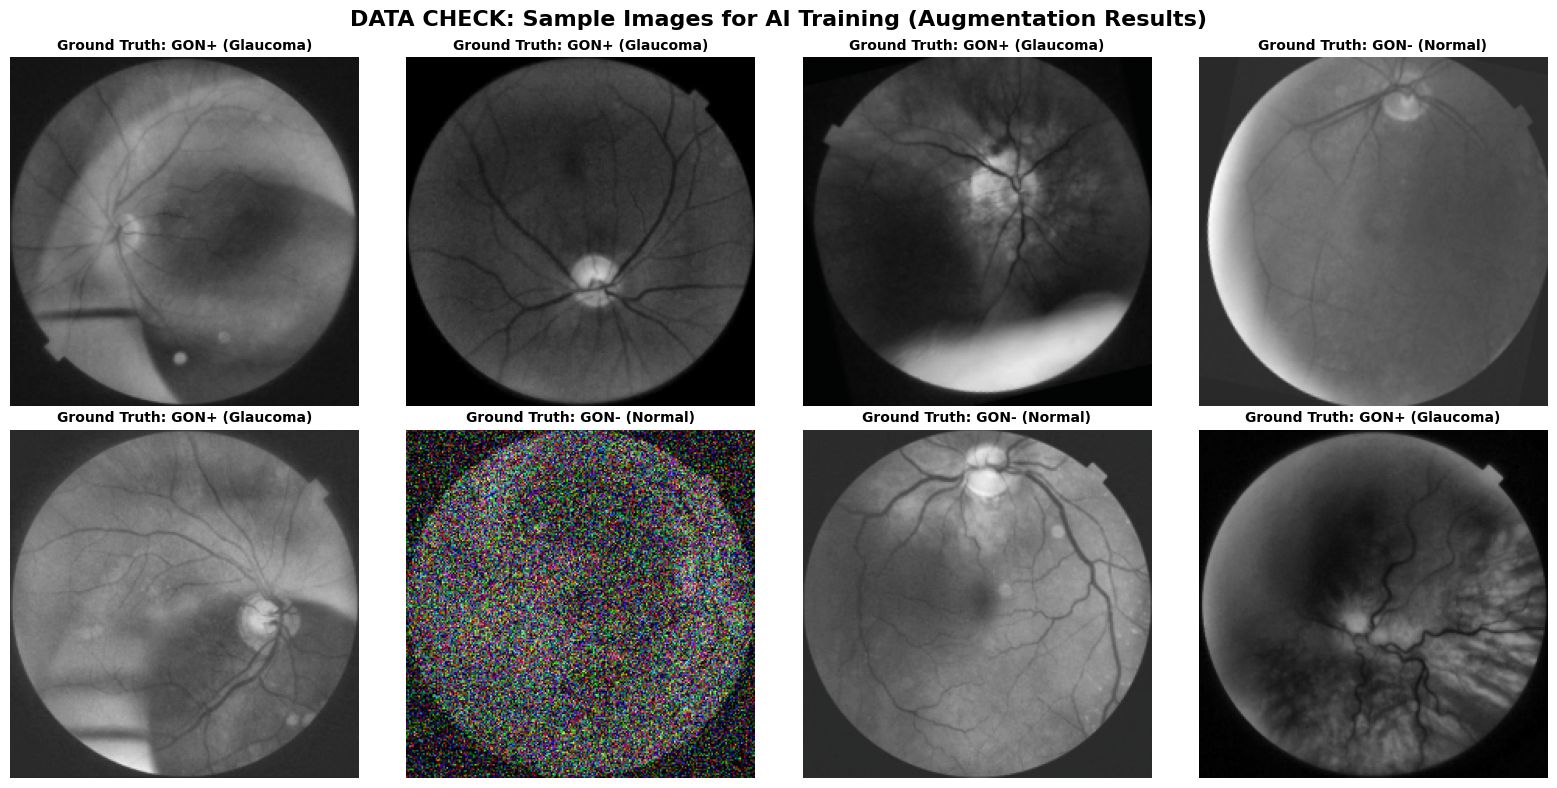

In [8]:
# ==========================================
# 5: IMAGE SAMPLE VISUALIZATION (SANITY CHECK)
# ==========================================
# 1. Take one batch of data (16 images) from the train_loader
# next(iter(...)) acts like taking a sample spoonful
images, labels = next(iter(train_loader))

# 2. Prepare the plot canvas (size 16x8 inches)
plt.figure(figsize=(16, 8))

# 3. Display the first 8 images from the batch
for i in range(8): 
    # Convert tensor format (C, H, W) back to numpy format (H, W, C)
    img = images[i].permute(1, 2, 0).numpy()
    
    # COLOR NORMALIZATION KEY: Reverse the Normalization process (Un-normalize)
    # Without this, the images will look dark or distorted
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img * std) + mean
    
    # Ensure pixel values stay within the range of 0 to 1
    img = np.clip(img, 0, 1)
    
    # Determine label text
    label_text = "GON+ (Glaucoma)" if labels[i] == 1 else "GON- (Normal)"
    
    # Plotting in subplots (2 rows, 4 columns)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(f"Ground Truth: {label_text}", fontsize=10, fontweight='bold')
    plt.axis('off') # Turn off x-y axes for a cleaner look

# 4. Display the main title and render the images
plt.suptitle("DATA CHECK: Sample Images for AI Training (Augmentation Results)", fontsize=16, fontweight='black')
plt.tight_layout()
plt.show()

Detecting device: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


 Starting training process (Gradient Clipping + Cosine Annealing)...



Epoch 1 [Train]: 100%|██████████| 27/27 [00:08<00:00,  3.14it/s]


 Epoch 1 | Train Loss: 0.4002 | Val Loss: 0.2748 | LR: 9.99e-06
     Val Loss decreased! Model saved.


...

 Epoch 8 | Train Loss: 0.0799 | Val Loss: 0.2080 | LR: 9.39e-06
     Patience: 6/8


Epoch 9 [Train]: 100%|██████████| 27/27 [00:06<00:00,  4.03it/s]


 Epoch 9 | Train Loss: 0.0950 | Val Loss: 0.2219 | LR: 9.23e-06
     Patience: 7/8


Epoch 10 [Train]: 100%|██████████| 27/27 [00:06<00:00,  3.95it/s]


 Epoch 10 | Train Loss: 0.0761 | Val Loss: 0.2049 | LR: 9.05e-06
     Patience: 8/8

 EARLY STOPPING TRIGGERED!

 Scanning TEST DATA for final clinical report...

 CLINICAL EVALUATION REPORT
              precision    recall  f1-score   support

      Normal       0.79      1.00      0.88        23
    Glaucoma       1.00      0.91      0.95        68

    accuracy                           0.93        91
   macro avg       0.90      0.96      0.92        91
weighted avg       0.95      0.93      0.94        91



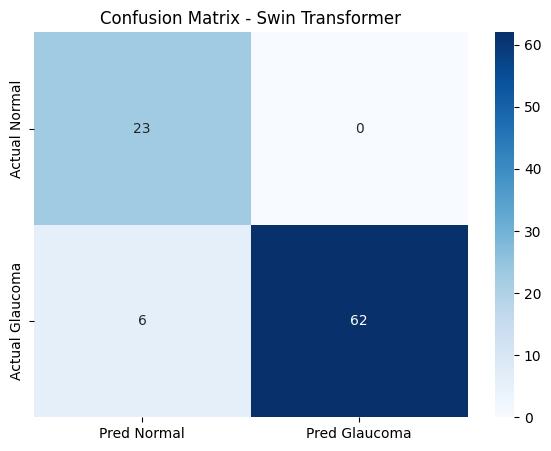

In [9]:
# ==========================================
# 2. SETUP MODEL & LOSS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Detecting device: {device}")

model = timm.create_model(
    'swin_tiny_patch4_window7_224', 
    pretrained=True, 
    num_classes=1,
    drop_path_rate=0.2 # Stochastic Depth Regularization
)
model = model.to(device)

# Loss with Class Imbalance handling
pos_weight_val = torch.tensor([class_weights[1]/class_weights[0]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

# Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2) 
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-7)

# ==========================================
# 3. TRAINING LOOP & EARLY STOPPING
# ==========================================
save_path = '/kaggle/working/swin_glaucoma_model_best.pth'
best_val_loss = float('inf')
patience, patience_counter = 8, 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\n Starting training process (Gradient Clipping + Cosine Annealing)...\n")
for epoch in range(50):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images, labels = images.to(device), labels.to(device).unsqueeze(1) 
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Keeps loss curves smooth
        optimizer.step()
        
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    scheduler.step()
        
    # Validation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_loss += v_loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    # Save Metrics
    metrics = {
        'train_loss': train_loss / len(train_loader),
        'val_loss': val_loss / len(val_loader),
        'train_acc': correct_train / total_train,
        'val_acc': correct_val / total_val
    }
    for k, v in metrics.items(): history[k].append(v)
    print(f" Epoch {epoch+1} | Train Loss: {metrics['train_loss']:.4f} | Val Loss: {metrics['val_loss']:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    # Early Stopping
    if metrics['val_loss'] < best_val_loss:
        best_val_loss = metrics['val_loss']
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
        print("     Val Loss decreased! Model saved.")
    else:
        patience_counter += 1
        print(f"     Patience: {patience_counter}/8")
        
    if patience_counter >= 8:
        print("\n EARLY STOPPING TRIGGERED!"); break

# ==========================================
# 4. EVALUATION PHASE ON TEST SET (FIXED)
# ==========================================
model.load_state_dict(torch.load(save_path))
model.eval()

# KEY: all_probs is now back!
all_preds, all_labels, all_probs = [], [], []

print("\n Scanning TEST DATA for final clinical report...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        probs = torch.sigmoid(outputs).squeeze() # Probability (0-1)
        preds = (probs > 0.5).float()            # Prediction (0 or 1)
        
        if probs.dim() == 0:
            probs, preds = probs.unsqueeze(0), preds.unsqueeze(0)
            
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy for further analysis
all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("\n" + "="*50)
print(" CLINICAL EVALUATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=["Normal", "Glaucoma"]))

# Confusion Matrix Visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Normal', 'Pred Glaucoma'], 
            yticklabels=['Actual Normal', 'Actual Glaucoma'])
plt.title("Confusion Matrix - Swin Transformer")
plt.show()

 Plotting performance for 10 Epochs...


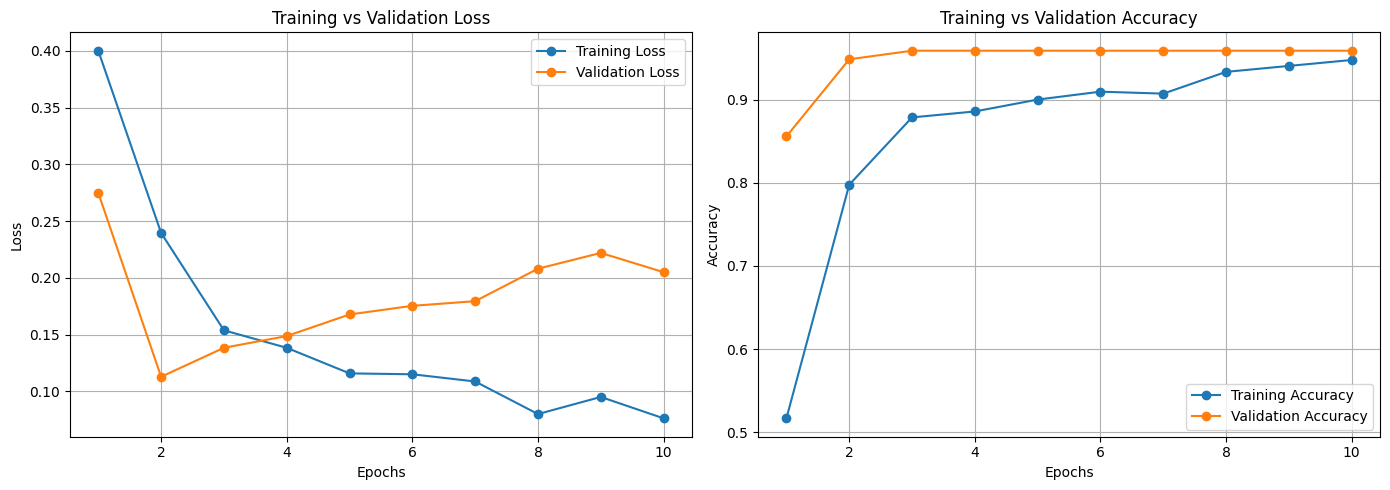

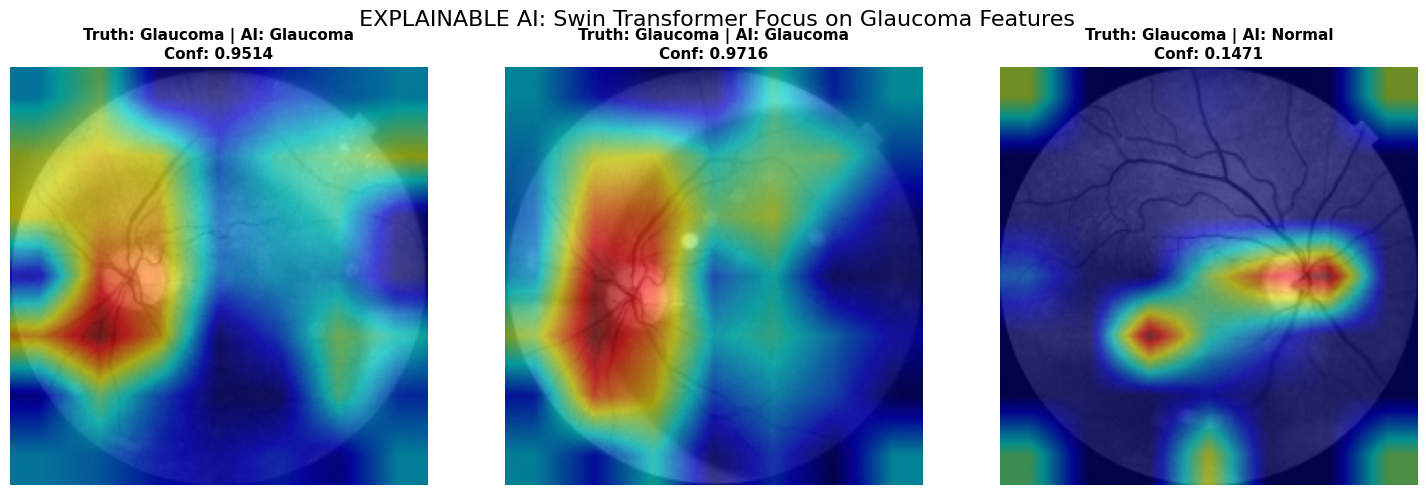


 SWIN TRANSFORMER (TINY) STRUCTURE ANALYSIS

 Generating architecture flowchart (PDF)...
 Flowchart successfully saved at: /kaggle/working/Flowchart_Swin_Transformer.pdf


In [10]:
# ==========================================
# 1. LEARNING CURVE VISUALIZATION
# ==========================================
# Detect actual number of epochs (important if Early Stopping was triggered)
actual_epochs = len(history['train_loss'])
epochs_range = range(1, actual_epochs + 1)

print(f" Plotting performance for {actual_epochs} Epochs...")

plt.figure(figsize=(14, 5))

# Plot Loss: Monitor convergence and signs of overfitting
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy: Observe prediction stability
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. GRAD-CAM++ SETUP (EXPLAINABLE AI)
# ==========================================
# Custom transformation to reconstruct spatial features from Transformer tensors
def reshape_transform(tensor, height=7, width=7):
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

# Retrieve the base model (anticipate cases where model is wrapped in DataParallel)
base_model = model.module if hasattr(model, 'module') else model

# Target: The final normalization layer before the classification head
target_layers = [base_model.layers[-1].blocks[-1].norm2]

# GradCAM++ chosen for its ability to better localize small features (optic nerve)
cam = GradCAMPlusPlus(model=base_model, 
                      target_layers=target_layers, 
                      reshape_transform=reshape_transform)

# ==========================================
# 3. XAI VISUALIZATION ON TEST SET
# ==========================================
images, labels = next(iter(test_loader))
plt.figure(figsize=(15, 5))

for i in range(3):
    input_tensor = images[i].unsqueeze(0).to(device)
    
    # Generate Heatmap for Glaucoma target class (Index 0)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])[0, :]
    
    # Un-normalize image for human visualization
    img_original = images[i].permute(1, 2, 0).cpu().numpy()
    img_original = (img_original * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img_original = np.clip(img_original, 0, 1)
    
    # Overlay Heatmap onto the original image
    visualization = show_cam_on_image(img_original, grayscale_cam, use_rgb=True)
    
    # Probability Prediction
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(base_model(input_tensor)).item()
    
    ground_truth = "Glaucoma" if labels[i].item() == 1 else "Normal"
    ai_prediction = "Glaucoma" if pred > 0.5 else "Normal"
    
    plt.subplot(1, 3, i + 1)
    plt.imshow(visualization)
    plt.title(f"Truth: {ground_truth} | AI: {ai_prediction}\nConf: {pred:.4f}", fontsize=11, fontweight='bold')
    plt.axis('off')

plt.suptitle(" EXPLAINABLE AI: Swin Transformer Focus on Glaucoma Features", fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 4. MODEL ARCHITECTURE DISSECTION
# ==========================================
print("\n" + "="*60)
print(" SWIN TRANSFORMER (TINY) STRUCTURE ANALYSIS")
print("="*60)

summary(base_model, 
        input_size=(16, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

# Automated Architecture Flowchart Generation
print("\n Generating architecture flowchart (PDF)...")
base_model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)
output = base_model(dummy_input)
arch_graph = make_dot(output, params=dict(list(base_model.named_parameters())))

arch_graph.format = 'pdf'
save_path_graph = '/kaggle/working/Flowchart_Swin_Transformer'
arch_graph.render(save_path_graph)

print(f" Flowchart successfully saved at: {save_path_graph}.pdf")

 PHASE 1: ERROR ANALYSIS (Threshold 0.5)
Analyzing 6 undetected Glaucoma patients...



/tmp/ipykernel_24/740472005.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


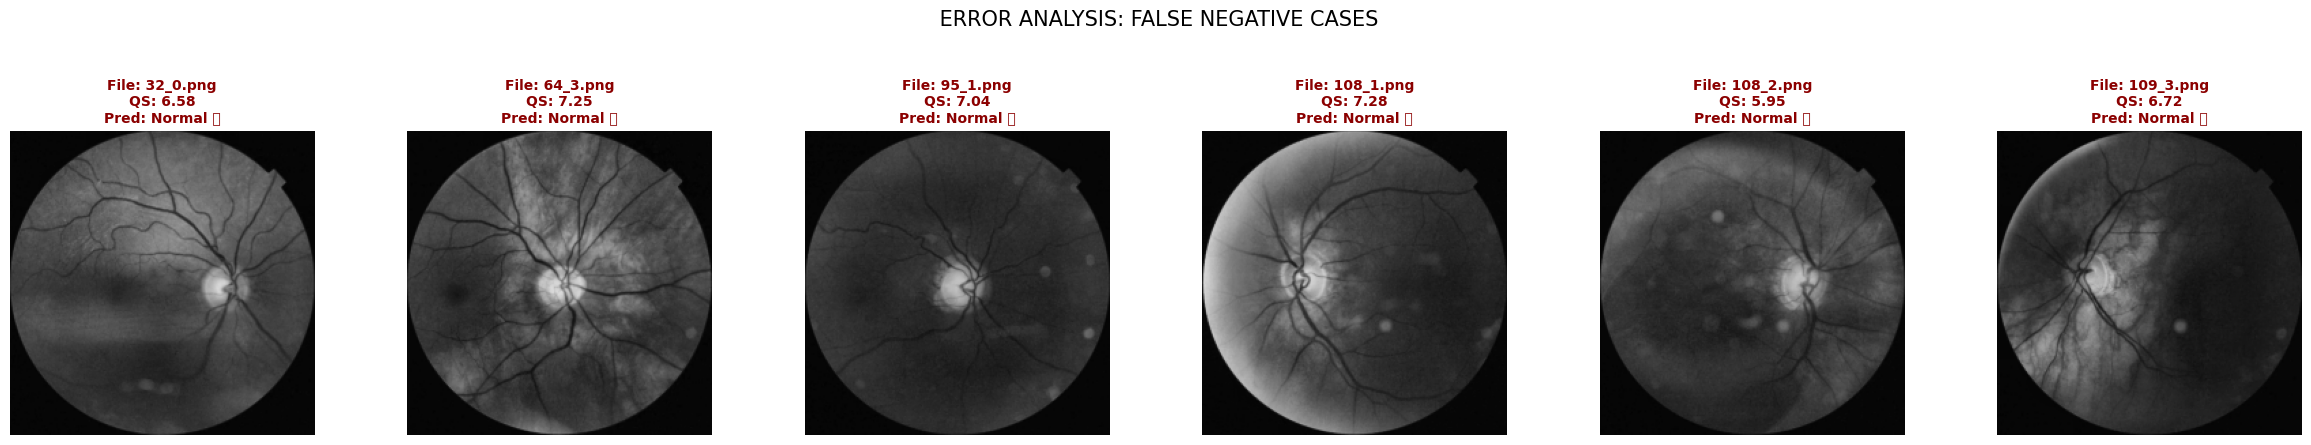


 PHASE 2: MEDICAL THRESHOLD MANEUVER
Default Threshold : 0.5000
Medical Threshold : 0.1471

 POST-MANEUVER STATISTICS:
FN: 0 (Missed) | FP: 0 (False Alarm)
Sensitivity: 1.0000 | Specificity: 1.0000


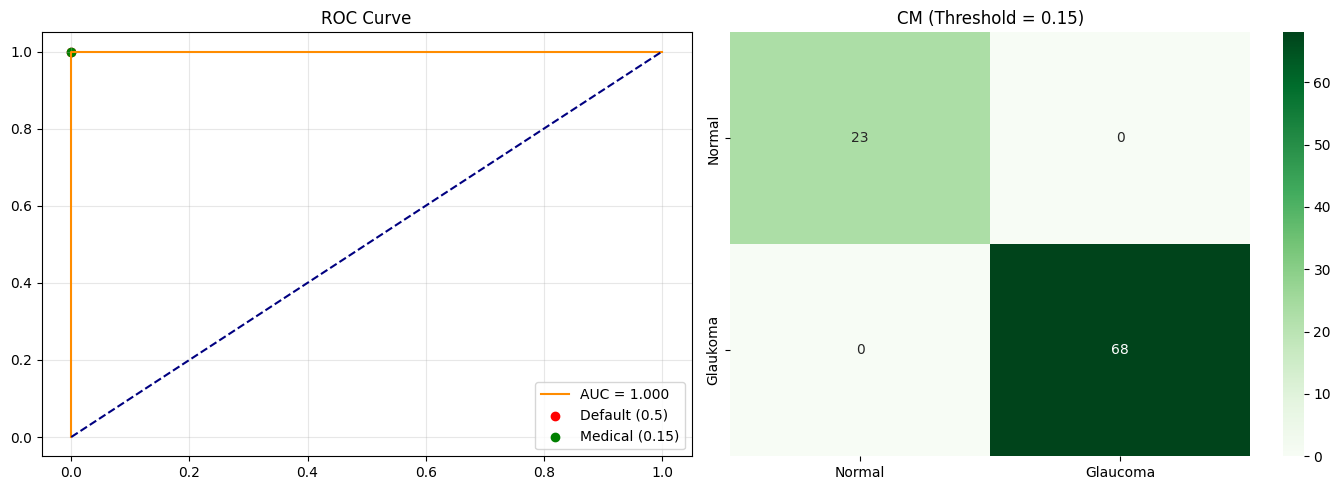


 PHASE 2.5: MOST UNCERTAIN CASES


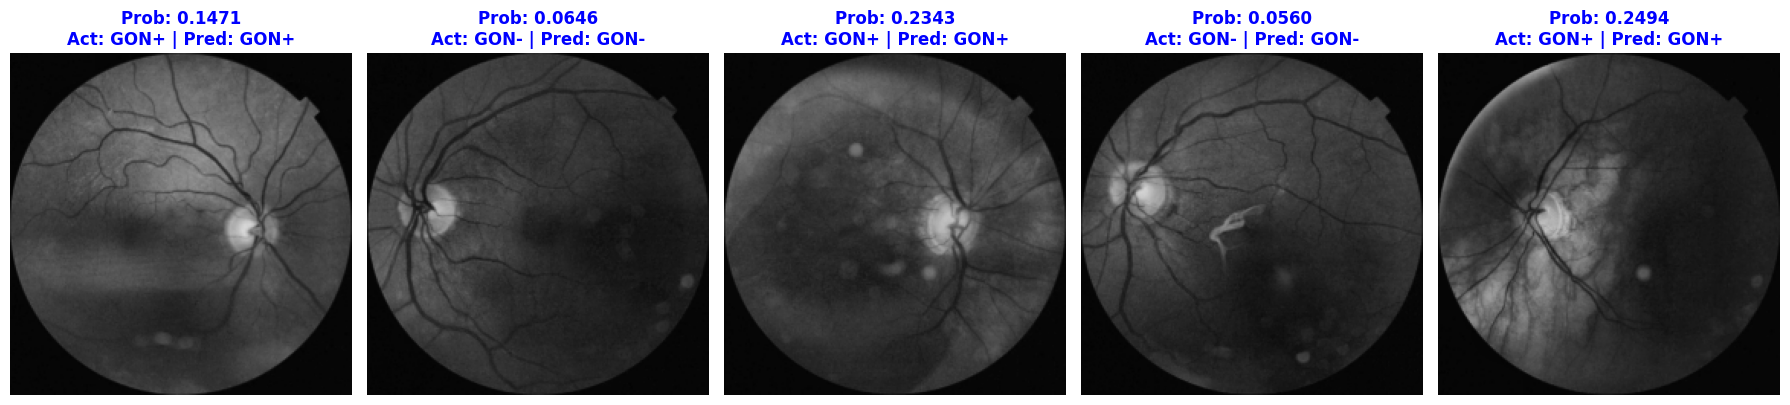


 PHASE 3: MODEL ROBUSTNESS REPORT
Ideal Accuracy   : 1.0000
Stress Accuracy  : 0.9121
Accuracy Drop    : 8.79%


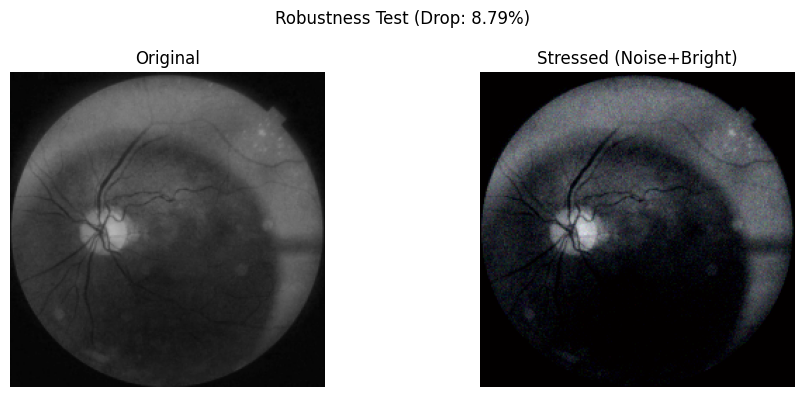

In [11]:
# ==========================================
# 🚨 PHASE 1: ERROR ANALYSIS (False Negatives)
# ==========================================
print("="*60)
print(" PHASE 1: ERROR ANALYSIS (Threshold 0.5)")
print("="*60)

# Convert to arrays for fast indexing
all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Track False Negatives: Actual Glaucoma (1), but Predicted Normal (0)
fn_indices = np.where((all_labels == 1) & (all_preds == 0))[0]
print(f"Analyzing {len(fn_indices)} undetected Glaucoma patients...\n")

if len(fn_indices) > 0:
    fig, axes = plt.subplots(1, len(fn_indices), figsize=(4 * len(fn_indices), 4))
    axes = np.atleast_1d(axes) 

    for i, idx in enumerate(fn_indices):
        row = test_df.iloc[idx]
        img = Image.open(row['valid_path'])
        
        axes[i].imshow(img)
        axes[i].set_title(f"File: {os.path.basename(row['valid_path'])}\nQS: {row.get('Quality Score', 'N/A')}\nPred: Normal ❌", 
                          fontsize=10, fontweight='bold', color='darkred')
        axes[i].axis('off')

    plt.suptitle(" ERROR ANALYSIS: FALSE NEGATIVE CASES", fontsize=15, y=1.1)
    plt.tight_layout(); plt.show()
else:
    print(" No False Negatives found at threshold 0.5!")

# ==========================================
#  PHASE 2: OPTIMAL THRESHOLD (ROC & YOUDEN'S J)
# ==========================================
print("\n" + "="*60)
print(" PHASE 2: MEDICAL THRESHOLD MANEUVER")
print("="*60)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Find Optimal Threshold using Youden's J statistic
optimal_threshold = thresholds[np.argmax(tpr - fpr)]

# Medical Threshold: Point where Recall (TPR) reaches nearly 100%
idx_medical = np.where(tpr >= 0.99)[0]
medical_threshold = thresholds[idx_medical[0]] if len(idx_medical) > 0 else optimal_threshold

# Apply Medical Threshold (capped at 1.0)
final_threshold = medical_threshold if medical_threshold <= 1.0 else 0.45
print(f"Default Threshold : 0.5000\nMedical Threshold : {final_threshold:.4f}")

# Re-evaluate with the new Threshold
new_preds = (all_probs >= final_threshold).astype(int)
cm_new = confusion_matrix(all_labels, new_preds)
tn, fp, fn, tp = cm_new.ravel()

print(f"\n POST-MANEUVER STATISTICS:\nFN: {fn} (Missed) | FP: {fp} (False Alarm)")
print(f"Sensitivity: {tp/(tp+fn):.4f} | Specificity: {tn/(tn+fp):.4f}")

# Plot ROC & Confusion Matrix
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.scatter(fpr[np.argmin(np.abs(thresholds - 0.5))], tpr[np.argmin(np.abs(thresholds - 0.5))], color='red', label='Default (0.5)')
plt.scatter(fpr[np.argmin(np.abs(thresholds - final_threshold))], tpr[np.argmin(np.abs(thresholds - final_threshold))], color='green', label=f'Medical ({final_threshold:.2f})')
plt.title('ROC Curve'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Glaucoma'], yticklabels=['Normal', 'Glaukoma'])
plt.title(f"CM (Threshold = {final_threshold:.2f})")
plt.tight_layout(); plt.show()

# ==========================================
#  PHASE 2.5: UNCERTAINTY ANALYSIS
# ==========================================
print("\n" + "="*60)
print(" PHASE 2.5: MOST UNCERTAIN CASES")
print("="*60)

# Take 5 images where the probability is closest to the threshold
uncertain_indices = np.abs(all_probs - final_threshold).argsort()[:5]

plt.figure(figsize=(18, 5))
for i, idx in enumerate(uncertain_indices):
    prob, actual_val = all_probs[idx], all_labels[idx]
    actual = "GON+" if actual_val == 1 else "GON-"
    pred = "GON+" if prob >= final_threshold else "GON-"
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(Image.open(test_df.iloc[idx]['valid_path']))
    plt.title(f"Prob: {prob:.4f}\nAct: {actual} | Pred: {pred}", 
              color='blue' if actual == pred else 'red', fontweight='bold')
    plt.axis('off')
plt.tight_layout(); plt.show()

# ==========================================
#  PHASE 3: STRESS TEST (MODEL ROBUSTNESS)
# ==========================================
print("\n" + "="*60)
print(" PHASE 3: MODEL ROBUSTNESS REPORT")
print("="*60)

def run_stress_test(model, loader, noise=0.1, bright=1.5, thres=final_threshold):
    model.eval()
    correct, total, s_orig, s_str = 0, 0, None, None
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
            if s_orig is None: s_orig = imgs[0].cpu().numpy()
            
            # Injection of Noise & Brightness
            imgs_str = torch.clamp((imgs + torch.randn_like(imgs) * noise) * bright, imgs.min(), imgs.max())
            if s_str is None: s_str = imgs_str[0].cpu().numpy()

            outputs = model(imgs_str)
            preds = (torch.sigmoid(outputs) >= thres).float()
            correct += (preds == lbls).sum().item(); total += lbls.size(0)
    return (correct / total), s_orig, s_str

acc_stress, img_orig, img_str = run_stress_test(model, test_loader)
accuracy_ideal = accuracy_score(all_labels, new_preds)
drop = (accuracy_ideal - acc_stress) * 100

print(f"Ideal Accuracy   : {accuracy_ideal:.4f}")
print(f"Stress Accuracy  : {acc_stress:.4f}")
print(f"Accuracy Drop    : {drop:.2f}%")

# Visual Comparison Plot
def unnorm(img):
    m, s = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img = img.transpose(1, 2, 0)
    return np.clip((img * s) + m, 0, 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(unnorm(img_orig)); plt.title("Original"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(unnorm(img_str)); plt.title("Stressed (Noise+Bright)"); plt.axis('off')
plt.suptitle(f"Robustness Test (Drop: {drop:.2f}%)")
plt.tight_layout(); plt.show()

### Model Export for Deployment
Once the training process is complete, please download the trained weight file located at:
`/kaggle/working/swin_glaucoma_model_best.pth` 

This file contains the optimal model parameters (State Dict) required for the deployment phase.